# Obtener el maximo de los modelos

Guia de las tecnicas estado del arte mas conocidas para la construccion de modelos.

In [1]:
# Ejecutar en caso de que la GPU este reservando toda la memoria innecesariamente (antes reiniciar el kernel)
from helpers.gpu_config import configure_gpu_memory_growth
gpus = configure_gpu_memory_growth()
print(gpus)

2026-07-11 19:43:02.465109: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-11 19:43:02.465142: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-11 19:43:02.466330: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-11 19:43:02.472537: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-07-11 19:43:03.905812: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-11 19:43:03.912294: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-11 19:43:03.912492: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

## Patrones arquitecturales avanzados

En secciones previas se analizo el patron *conexiones residuales*. Ahora se van a explorar 2 tipos de patrones importantes extra:
- *Batch Normalization*.
- *Deep Wise Separable Convolution*.

### Batch Normalization

La normalizacion es un concepto amplio que agrupa metodos que **permiten que diferentes muestras sean vistas por modelos de aprendizaje automatico de forma similar entre si**.

La forma de normalizacion mas comun es centrar los datos en 0 restando su media y darle a los datos una unidad de desviacion estandar dividiendolos por su desviacion estandar. Esto hace la asumcion de que los datos siguen una distribucion Gaussiana.

```
normalized_data = (data - np.mean(data, axis=...)) / np.std(data, axis=...)
```

La **normalizacion debe ser considerada luego de cada transformacion efectuada por la red**.
Incluso si los datos de entrada tienen media 0 y varianza unitaria nada asegura que su salida mantendra el patron.

En keras la normalizacion se puede aplicar con la capa `BatchNormalization`. El aplicarla es ayuda con la propagacion del gradiente asi como las conexiones residuales, lo que previene el desvanecimiento de gradiente y permite redes mas profundas.

La capa `BatchNormalization` es usada en multiples arquitecturas de red disponibles en *Keras*. Como *ResNet50*, *Inception V3* y *Xception*. Tipicamente se la usa despues de una red convoucional o densamente conectada.

```
# Post Convolucional
conv_model.add(layers.Conv2D(32, 3, activation='relu'))
conv_model.add(layers.BatchNormalization())
# Post Densa
dense_model.add(layers.Dense(32, activation='relu'))
dense_model.add(layers.BatchNormalization())
```

Para la mayoria de casos y con la configuracion default de *image_data_format : ~/.keras/keras.json* el parametro de `BatchNormalization` *data_format* vale *"channel_last" (batch_size, height, width, channels)* por lo que usar $axis = -1 (default)$ es correcto. En caso de que *data_format* valga *"channel_firs" (batch_size, channels, height, width)* entonces puede interesar otra configuracion como $axis = 1$.

#### Ejemplo - Cats Vs Dogs "Normales"

Para ilustrar la utilidad del metodo se repite el experimento realizado en [5.2.cats-vs-dogs](5.2.cats-vs-dogs.ipynb) donde se entrena un modelo clasificador de imagenes de perros y de gatos. Con la adicion de capas `BatchNormalization` luego de cada capa Convolucional.

**Nota:** Se agrega `use_bias=False` en las capas `Conv2D` ya que el desplazamiento *bias* de esta capa es neutralizado por el *beta* de `Batchnormalization`. Al escribir las ecuaciones se termina llegando a un solo termino de desplazamiento al usar los 2 por lo que el **espacio hipotetico con 1 termino = espacio hipotetico con 2 terminos**. Por tanto, desactivar *bias* en `Conv2D` evita computo innecesario. Respaldado en [[Lof, 2015] (Pendiente de comprobación)](https://arxiv.org/pdf/1502.03167).

In [2]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3), use_bias=False))
model.add(layers.BatchNormalization())
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu', use_bias=False))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu', use_bias=False))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu', use_bias=False))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      864       
                                                                 
 batch_normalization (Batch  (None, 148, 148, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18432     
                                                                 
 batch_normalization_1 (Bat  (None, 72, 72, 64)        256       
 chNormalization)                                                
                                                        

2026-07-11 15:50:40.681864: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-11 15:50:40.682119: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-11 15:50:40.682307: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Se compila el modelo, mismo error, misma optimizacion.

In [3]:
from tensorflow.keras import optimizers

model.compile(loss='binary_crossentropy', 
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc']
              )

Se preparan los datos de entrenamiento y validación.

Se usa la misma carpeta de datos y estrategia de *Data Augmentation* que se uso en la mejor version del modelo original.

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_dir = os.path.expanduser('./datasets/kaggle_original_data/cats_and_dogs_small')
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255) # NO aumentar los datos de validación.

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Entrenamiento

In [6]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
history = model.fit(
    train_generator,
    #steps_per_epoch=100,
    epochs=100,
    validation_data=validation_generator,
    #validation_steps=50
    )

Epoch 1/100
63/63 [==============================] - 11s 168ms/step - loss: 0.7272 - acc: 0.6345 - val_loss: 1.8173 - val_acc: 0.5000
Epoch 2/100
63/63 [==============================] - 11s 167ms/step - loss: 0.6787 - acc: 0.6420 - val_loss: 1.8094 - val_acc: 0.5000
Epoch 3/100
63/63 [==============================] - 10s 166ms/step - loss: 0.6431 - acc: 0.6605 - val_loss: 1.7889 - val_acc: 0.5000
Epoch 4/100
63/63 [==============================] - 11s 167ms/step - loss: 0.6068 - acc: 0.6850 - val_loss: 1.7480 - val_acc: 0.5020
Epoch 5/100
63/63 [==============================] - 11s 167ms/step - loss: 0.5805 - acc: 0.7110 - val_loss: 0.9226 - val_acc: 0.5690
Epoch 6/100
63/63 [==============================] - 10s 166ms/step - loss: 0.5696 - acc: 0.7300 - val_loss: 0.8880 - val_acc: 0.6100
Epoch 7/100
63/63 [==============================] - 11s 167ms/step - loss: 0.5571 - acc: 0.7125 - val_loss: 0.7934 - val_acc: 0.6590
Epoch 8/100
63/63 [==============================] - 11s 167ms

In [7]:
model.save('./models/7.3.cats_and_dogs_small_normalized.h5')

/workspace/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


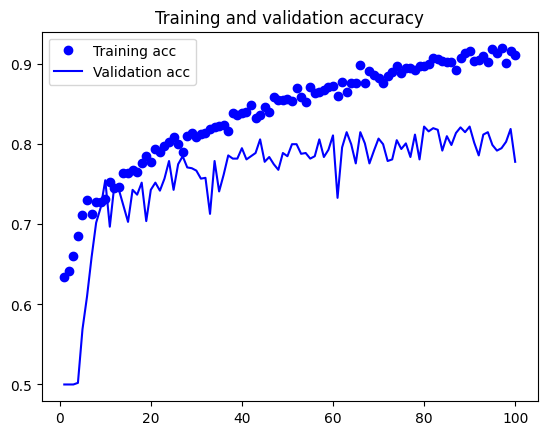

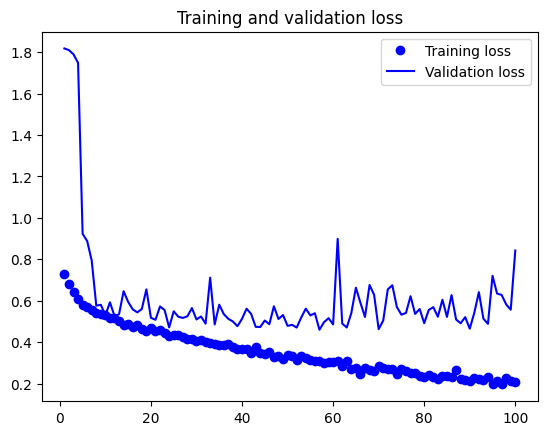

In [8]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [9]:
import numpy as np

best_acc_epoch = np.argmax(history.history["val_acc"]) + 1
best_loss_epoch = np.argmin(history.history["val_loss"]) + 1

print("Mejor accuracy de validación:")
print(best_acc_epoch, history.history["val_acc"][best_acc_epoch - 1])

print("Menor loss de validación:")
print(best_loss_epoch, history.history["val_loss"][best_loss_epoch - 1])

Mejor accuracy de validación:
80 0.8220000267028809
Menor loss de validación:
57 0.4598347842693329


El rendimiento cambia drasticamente respecto a lo visto en [5.2.cats-vs-dogs](5.2.cats-vs-dogs.ipynb). En vez de una curva que crece o decrece gradualmente ahora se ven movimientos drasticos al inicio, seguidos de cambios lentos durante las siguientes 90 epocas. 

El cambio en velocidad muestra que el modelo detecta cambios generales mucho mas rapido. Esto se apoya con que la normalizacion trata las features encontradas de forma que 2 features que antes no se notaba que son similares ahora es evidente. Pareciera que esto **permite identificar las caracteristicas generales imagenes mas rapido**.

En el caso de *Loss* la validacion se estanca mientras que train aumenta. El mejor valor parece rondear los $0.46$ peor que los $0.45$ de la version anterior. A partir de la epoca 70 pareciera iniciar un ligero *overfitting*. No obstante, no se refleja en el *Acc*. 

En el caso del ***Acc* la mejora fue notoria**. Antes lo maximo que se alcanzo fue $0.80$, pero ahora el los mejores resultados van alredero fue de $0.82$. La tendencia vista en la version anterior era que mas epocas probablemente mejoren el *Acc*. Este modelo usa las mismas epocas, pero el poder aprender mas rapido ayuda a que alcance la misma situacion que el primero en la epoca 100 antes, alrededor de su epoca 60. Permitiendo que pueda dedicar las 40 epocas restantes a mejorar ese resultado. 

Por lo visto en el experimento parece que ***BatchNormalization*** contribuye en la **velocidad** con la que el modelo se ajusta a los patrones de los datos. Lo que **permite llegar a los mismos resultados pero mas rapido**.

De la teoria tambien sabemos que **BatchNormalization** tambien ayuda con la propagacion del gradiente, probablemente debido a que redimenciona los valores a rangos manejables.

### Deepwise Separable Convolution

Convoluciones separables en profundidad. Se trata de una capa que se puede usar como **remplazo** para las capas de ***drop-in* en Convoluciones 2D**. Con la caracteristica de que hacen el modelo **mas ligero** (al reducir los parametros entrenables) y **mas rapido** (menos operaciones de punto flotante). Ademas, logra **mejorar un poco las metricas de resolucion** de la tarea.

La capa `SeparableConv2D` de keras implementa esto. El 'truco' radica en ejecutar **convoluciones en cada canal de la entrada de forma independiente** y luego mezclar todos los canales de salida mediante una convolucion de ancho unitario ($1x1$). A continuacion se muestra un diagrama ilustrativo.

<img src="images/7.3.DeepwiseConvolution2D.png" style="width:350px;">

Tiene sentido al razonar que esto separa el aprendizaje de caracteristicas espaciales del aprendizaje de caracteristicas por canal. Al final, en la mayoria de los casos las caracteristicas espaciales estan altamente correlacionadas mientras que las caracteristicas por canal suelen ser bastante independientes.

Este metodo de ejecutar las convoluciones es mas representacionalmente eficiente, por lo que permite lograr mejores representaciones usando menos datos.

Sus ventajas se vuelven relevantes cuando uno entrena pequeños modelos con datos limitados. 

Las Convoluciones Separables en Profundidad son la base de la arquitectura *Xception* que viene incluida en *Keras*.

A continuacion se muestra como se construye una red ligera para la tarea de clasificacion de imagenes con un dataset pequeño.

In [ ]:
from keras.models import Sequential
from keras import layers
height = 64
width = 64
channels = 3
num_classes = 10
model = Sequential()
model.add(layers.SeparableConv2D(32, 3,
activation='relu',
input_shape=(height, width, channels,)))
model.add(layers.SeparableConv2D(64, 3, activation='relu'))
model.add(layers.MaxPooling2D(2))
model.add(layers.SeparableConv2D(64, 3, activation='relu'))
model.add(layers.SeparableConv2D(128, 3, activation='relu'))
model.add(layers.MaxPooling2D(2))
model.add(layers.SeparableConv2D(64, 3, activation='relu'))
model.add(layers.SeparableConv2D(128, 3, activation='relu'))
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(num_classes, activation='softmax'))
model.compile(optimizer='rmsprop', loss='categorical_crossentropy')

#### Ejemplo - Cats Vs Dogs

Tener el rendimiento de este modelo no sirve sin la linea base con la que compararlo. Para ello se construo un modelo con las tecnicas que el mismo mejora. La tarea a resolver va a ser la clasificacion de imagenes de perros y gatos vista en el modelo anterior.

In [5]:
from keras import optimizers
from keras.models import Sequential
from keras import layers

model = Sequential()
model.add(layers.SeparableConv2D(32, 3, activation='relu', input_shape=(150, 150, 3,), use_bias=False))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2))
model.add(layers.SeparableConv2D(64, 3, activation='relu', use_bias=False))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2))
model.add(layers.SeparableConv2D(128, 3, activation='relu', use_bias=False))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2))
model.add(layers.SeparableConv2D(128, 3, activation='relu', use_bias=False))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 separable_conv2d_8 (Separa  (None, 148, 148, 32)      123       
 bleConv2D)                                                      
                                                                 
 batch_normalization_8 (Bat  (None, 148, 148, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 74, 74, 32)        0         
 g2D)                                                            
                                                                 
 separable_conv2d_9 (Separa  (None, 72, 72, 64)        2336      
 bleConv2D)                                                      
                                                                 
 batch_normalization_9 (Bat  (None, 72, 72, 64)       

La cantidad de elementos paso de $3,454,177 (13.18 MB)$ a $3,242,460 (12.37 MB)$. El uso de capas 'SeparableConnv2D' redujo la cantidad de parametros entrenables en $211,717$ unidades (~$6\%$).

In [6]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    )

Epoch 1/100


2026-07-11 19:44:05.818678: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-07-11 19:44:06.595251: I external/local_xla/xla/service/service.cc:168] XLA service 0x792434595ee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-11 19:44:06.595278: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2026-07-11 19:44:06.600712: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783799046.643212  177626 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 [==============================] - 14s 169ms/step - loss: 0.9786 - acc: 0.5770 - val_loss: 0.6962 - val_acc: 0.5000
Epoch 2/100
63/63 [==============================] - 11s 166ms/step - loss: 0.7344 - acc: 0.6165 - val_loss: 0.7225 - val_acc: 0.5000
Epoch 3/100
63/63 [==============================] - 10s 166ms/step - loss: 0.6703 - acc: 0.6395 - val_loss: 0.7691 - val_acc: 0.5000
Epoch 4/100
63/63 [==============================] - 11s 167ms/step - loss: 0.6378 - acc: 0.6520 - val_loss: 0.9531 - val_acc: 0.5000
Epoch 5/100
63/63 [==============================] - 11s 167ms/step - loss: 0.5869 - acc: 0.6935 - val_loss: 0.7289 - val_acc: 0.5000
Epoch 6/100
63/63 [==============================] - 11s 167ms/step - loss: 0.6002 - acc: 0.6730 - val_loss: 0.7706 - val_acc: 0.5000
Epoch 7/100
63/63 [==============================] - 11s 168ms/step - loss: 0.5794 - acc: 0.6955 - val_loss: 0.7244 - val_acc: 0.5480
Epoch 8/100
63/63 [==============================] - 11s 168ms/step - loss

In [11]:
model.save('./models/7.3.cats_and_dogs_small_normalized_separableconv.h5')

/workspace/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Resultados:

Mejor accuracy de validación:
96 0.7879999876022339
Menor loss de validación:
33 0.5129930973052979


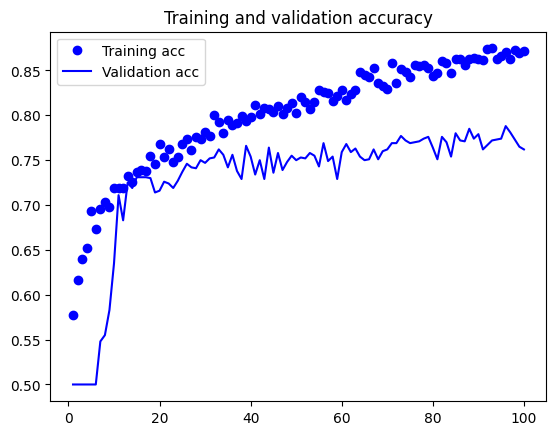

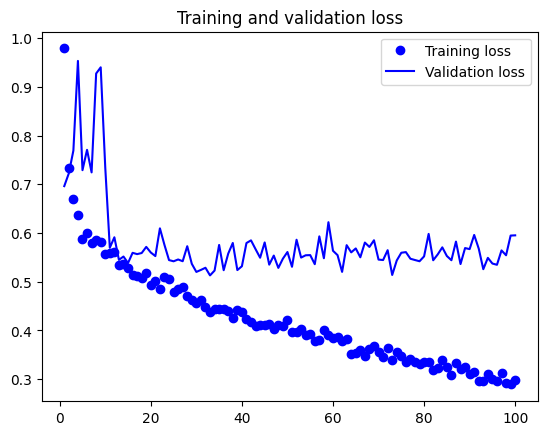

In [10]:
import matplotlib.pyplot as plt
import numpy as np

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
best_acc_epoch = np.argmax(history.history["val_acc"]) + 1
best_loss_epoch = np.argmin(history.history["val_loss"]) + 1

print("Mejor accuracy de validación:")
print(best_acc_epoch, history.history["val_acc"][best_acc_epoch - 1])
print("Menor loss de validación:")
print(best_loss_epoch, history.history["val_loss"][best_loss_epoch - 1])

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

El comportamiento de las curvas es similar al los obtenidos antes. Probablemente por que se mantuvieron las capas *BatchNormalization*.

El *Loss* empeora en $0.05$ respecto a la solucion anterior y el *Acc* esta $0.03$ por abajo.

El peso del modelo se redujo en ~$6\%$. 

En general, el uso de las capas significo una **reduccion de peso a costo de un rendimiento ligeramente peor** (Hay que repetir la prueba varias veces para ver si el comportamiento es consistente, puede que en otro dataset con imagenes donde la diferencia de canales sea mas significativa el rendimiento del patron mejore respeto a su alternativa *Conv2D*).

### TTT
...